In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/achilov15/labeledfr/reviewed_reviewed_reviewed_reviewed_french_labeled 3136.csv
/kaggle/input/datasets/achilov15/reviewed-llm-dataset/reviewed_llm_called_dataset.csv
/kaggle/input/datasets/achilov15/human-reviewed-absa-dataset/human_reviewed.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/achilov15/human-reviewed-absa-dataset/human_reviewed.csv")
llm_dataset = pd.read_csv("/kaggle/input/datasets/achilov15/reviewed-llm-dataset/reviewed_llm_called_dataset.csv")

In [4]:
df.head()

,id,text,stars,aspect,polarity,proba_predicted_label,confidence,proba_conflict,proba_negative,proba_neutral,...,llm_reason,final_aspect,final_polarity,human_checked,corrected_aspect,corrected_polarity,keep,comment,threshold,timestamp
0,0,Came Saturday w/ friends at 11:30am. Half off ...,5.0,Saturday w/ friends,positive,positive,0.952047,0.007945,0.010735,0.029272,...,NaN,Saturday w/ friends,positive,True,Saturday w/ friends,positive,1,NaN,0.6,2026-07-13 17:44:48.983523
1,0,Came Saturday w/ friends at 11:30am. Half off ...,5.0,Half,positive,positive,0.946624,0.008993,0.012698,0.031684,...,NaN,Half,positive,True,Half,positive,1,NaN,0.6,2026-07-13 17:44:48.983535
2,0,Came Saturday w/ friends at 11:30am. Half off ...,5.0,hour,positive,positive,0.954948,0.007601,0.010260,0.027191,...,NaN,hour,positive,True,hour,positive,1,NaN,0.6,2026-07-13 17:44:48.983541
3,0,Came Saturday w/ friends at 11:30am. Half off ...,5.0,shelf liqueur,positive,positive,0.958315,0.007327,0.009825,0.024534,...,NaN,shelf liqueur,positive,True,shelf liqueur,positive,1,NaN,0.6,2026-07-13 17:44:48.983547
4,0,Came Saturday w/ friends at 11:30am. Half off ...,5.0,Mary EVER,positive,positive,0.958103,0.007185,0.009819,0.024893,...,NaN,Mary EVER,positive,True,Mary EVER,positive,1,NaN,0.6,2026-07-13 17:44:48.983552


In [5]:
df.columns

Index(['id', 'text', 'stars', 'aspect', 'polarity', 'proba_predicted_label',
       'confidence', 'proba_conflict', 'proba_negative', 'proba_neutral',
       'proba_positive', 'llm_called', 'llm_raw_response', 'llm_aspect',
       'llm_polarity', 'llm_change_needed', 'llm_reason', 'final_aspect',
       'final_polarity', 'human_checked', 'corrected_aspect',
       'corrected_polarity', 'keep', 'comment', 'threshold', 'timestamp'],
      dtype='object')

In [6]:
from sklearn.metrics import accuracy_score

polarity_acc = accuracy_score(
    df["corrected_polarity"],
    df["final_polarity"]
)

print(f"Polarity Accuracy: {polarity_acc:.4f}")

Polarity Accuracy: 0.9467


In [7]:
df.columns

Index(['id', 'text', 'stars', 'aspect', 'polarity', 'proba_predicted_label',
       'confidence', 'proba_conflict', 'proba_negative', 'proba_neutral',
       'proba_positive', 'llm_called', 'llm_raw_response', 'llm_aspect',
       'llm_polarity', 'llm_change_needed', 'llm_reason', 'final_aspect',
       'final_polarity', 'human_checked', 'corrected_aspect',
       'corrected_polarity', 'keep', 'comment', 'threshold', 'timestamp'],
      dtype='object')

# All Dataset

In [8]:
from sklearn.metrics import classification_report

print(
    classification_report(
        df["corrected_polarity"],
        df["final_polarity"],
        digits=4
    )
)

              precision    recall  f1-score   support

    conflict     1.0000    1.0000    1.0000         5
    negative     0.9137    0.8933    0.9034       759
     neutral     0.9708    0.7444    0.8426       446
    positive     0.9515    0.9875    0.9691      3196

    accuracy                         0.9467      4406
   macro avg     0.9590    0.9063    0.9288      4406
weighted avg     0.9470    0.9467    0.9450      4406



In [9]:
print("Pipeline Accuracy:",
      accuracy_score(df["corrected_polarity"],
                     df["final_polarity"]))

print(classification_report(
    df["corrected_polarity"],
    df["final_polarity"],
    digits=4
))

Pipeline Accuracy: 0.9466636404902405
              precision    recall  f1-score   support

    conflict     1.0000    1.0000    1.0000         5
    negative     0.9137    0.8933    0.9034       759
     neutral     0.9708    0.7444    0.8426       446
    positive     0.9515    0.9875    0.9691      3196

    accuracy                         0.9467      4406
   macro avg     0.9590    0.9063    0.9288      4406
weighted avg     0.9470    0.9467    0.9450      4406



In [10]:
print(
    classification_report(
        df["corrected_polarity"],
        df["polarity"],
        digits=2
    )
)

              precision    recall  f1-score   support

    conflict       0.00      0.00      0.00         5
    negative       0.73      0.75      0.74       759
     neutral       0.62      0.40      0.49       446
    positive       0.92      0.96      0.94      3196

    accuracy                           0.87      4406
   macro avg       0.57      0.53      0.54      4406
weighted avg       0.86      0.87      0.86      4406



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
from sklearn.metrics import accuracy_score

model_acc = accuracy_score(df["corrected_polarity"], df["polarity"])
pipeline_acc = accuracy_score(df["corrected_polarity"], df["final_polarity"])

print(f"Model accuracy   : {model_acc:.4f}")
print(f"Pipeline accuracy: {pipeline_acc:.4f}")
print(f"Improvement      : {pipeline_acc - model_acc:+.4f}")

Model accuracy   : 0.8661
Pipeline accuracy: 0.9467
Improvement      : +0.0806


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Golden labels
y_true = df["corrected_polarity"]

y_pred_absa = df["proba_predicted_label"]
y_pred_llm = df["final_polarity"]

def calculate_metrics(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    precision_weighted, recall_weighted, f1_weighted, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted
    }

absa_metrics = calculate_metrics(y_true, y_pred_absa)
llm_metrics = calculate_metrics(y_true, y_pred_llm)

comparison = pd.DataFrame({
    "ABSA model": absa_metrics,
    "LLM": llm_metrics
})

print(comparison)

             ABSA model       LLM
Accuracy       0.833863  0.946664
Macro F1       0.455255  0.928794
Weighted F1    0.811521  0.945044


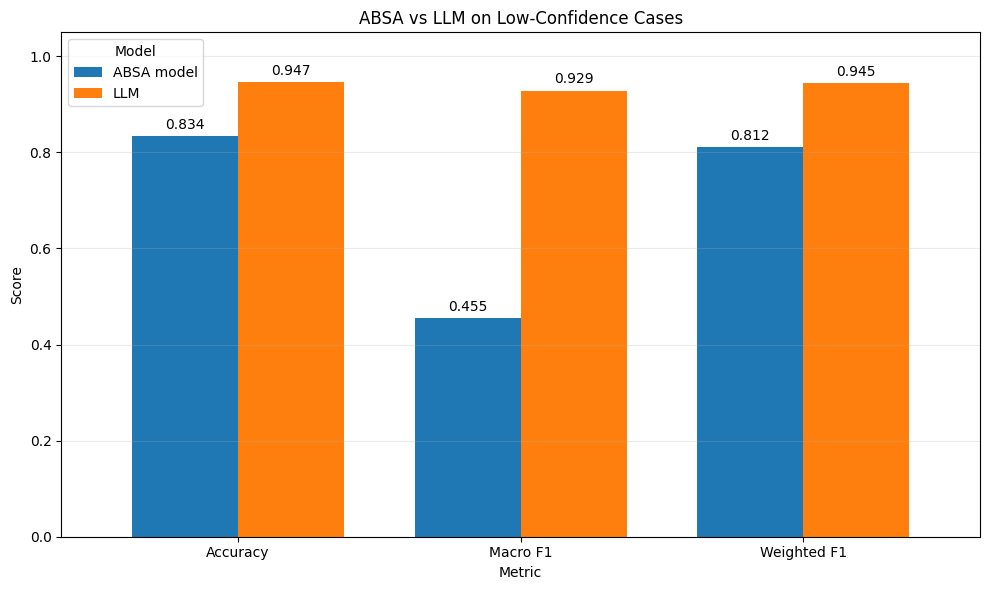

In [20]:
ax = comparison.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title("ABSA vs LLM on Low-Confidence Cases")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

labels = ["conflict", "negative", "neutral", "positive"]

absa_report = classification_report(
    y_true,
    y_pred_absa,
    labels=labels,
    output_dict=True,
    zero_division=0
)

llm_report = classification_report(
    y_true,
    y_pred_llm,
    labels=labels,
    output_dict=True,
    zero_division=0
)

f1_comparison = pd.DataFrame({
    "ABSA model": [
        absa_report[label]["f1-score"]
        for label in labels
    ],
    "LLM": [
        llm_report[label]["f1-score"]
        for label in labels
    ]
}, index=labels)

print(f1_comparison)

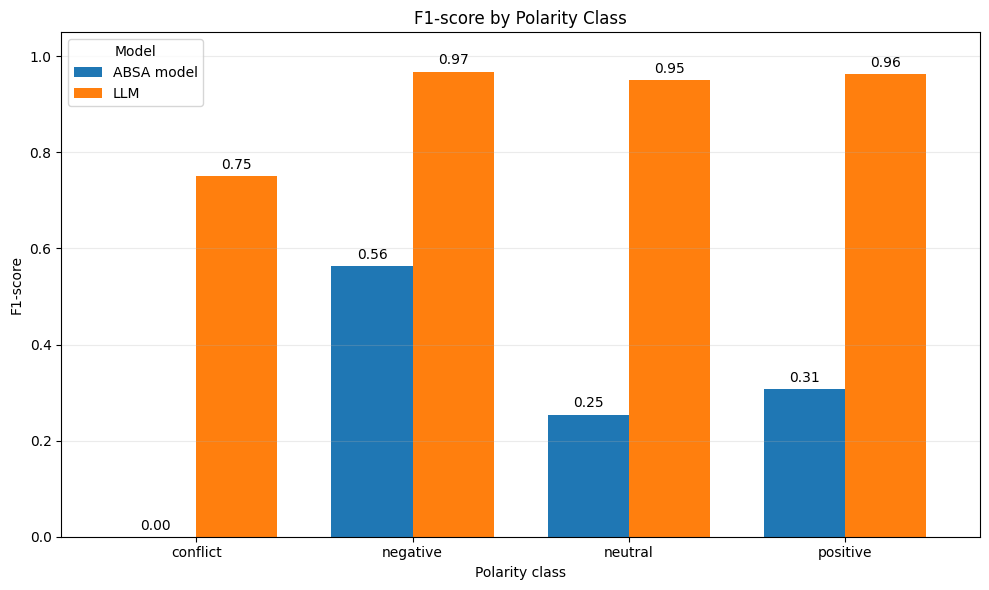

In [21]:
ax = f1_comparison.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title("F1-score by Polarity Class")
plt.xlabel("Polarity class")
plt.ylabel("F1-score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

# Samples where llm was called 

In [12]:
from sklearn.metrics import classification_report

print(
    classification_report(
        llm_dataset["corrected_polarity"],
        llm_dataset["final_polarity"],
        digits=4
    )
)

              precision    recall  f1-score   support

    conflict     0.6000    1.0000    0.7500         3
    negative     0.9507    0.9863    0.9682       293
     neutral     0.9783    0.9259    0.9514       243
    positive     0.9625    0.9625    0.9625       160

    accuracy                         0.9599       699
   macro avg     0.8729    0.9687    0.9080       699
weighted avg     0.9615    0.9599    0.9601       699



In [13]:
from sklearn.metrics import classification_report

print(
    classification_report(
        llm_dataset["corrected_polarity"],
        llm_dataset["polarity"],
        digits=4
    )
)

              precision    recall  f1-score   support

    conflict     0.0000    0.0000    0.0000         3
    negative     0.5333    0.6280    0.5768       293
     neutral     0.4195    0.3004    0.3501       243
    positive     0.4111    0.4625    0.4353       160

    accuracy                         0.4735       699
   macro avg     0.3410    0.3477    0.3406       699
weighted avg     0.4635    0.4735    0.4631       699



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
print("Model labels:")
print(df["polarity"].value_counts())

print()

print("Ground truth:")
print(df["corrected_polarity"].value_counts())

print()

print("Pipeline:")
print(df["final_polarity"].value_counts())

Model labels:
polarity
negative    345
positive    180
neutral     174
Name: count, dtype: int64

Ground truth:
corrected_polarity
negative    293
neutral     243
positive    160
conflict      3
Name: count, dtype: int64

Pipeline:
final_polarity
negative    304
neutral     230
positive    160
conflict      5
Name: count, dtype: int64


In [9]:
labeled_data = pd.read_csv("/kaggle/input/datasets/achilov15/labeledfr/reviewed_reviewed_reviewed_reviewed_french_labeled 3136.csv")


print(
    classification_report(
        labeled_data["corrected_polarity"],
        labeled_data["polarity"],
        digits=2
    )
)

              precision    recall  f1-score   support

    conflict       0.00      0.00      0.00         5
    negative       0.76      0.76      0.76       779
     neutral       0.62      0.43      0.51       418
    positive       0.93      0.96      0.95      3204

    accuracy                           0.88      4406
   macro avg       0.58      0.54      0.55      4406
weighted avg       0.87      0.88      0.87      4406



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Golden labels
y_true = llm_dataset["corrected_polarity"]

y_pred_absa = llm_dataset["proba_predicted_label"]
y_pred_llm = llm_dataset["final_polarity"]

def calculate_metrics(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    precision_weighted, recall_weighted, f1_weighted, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted
    }

absa_metrics = calculate_metrics(y_true, y_pred_absa)
llm_metrics = calculate_metrics(y_true, y_pred_llm)

comparison = pd.DataFrame({
    "ABSA model": absa_metrics,
    "LLM": llm_metrics
})

print(comparison)

             ABSA model       LLM
Accuracy       0.426323  0.959943
Macro F1       0.281033  0.908012
Weighted F1    0.394659  0.960099


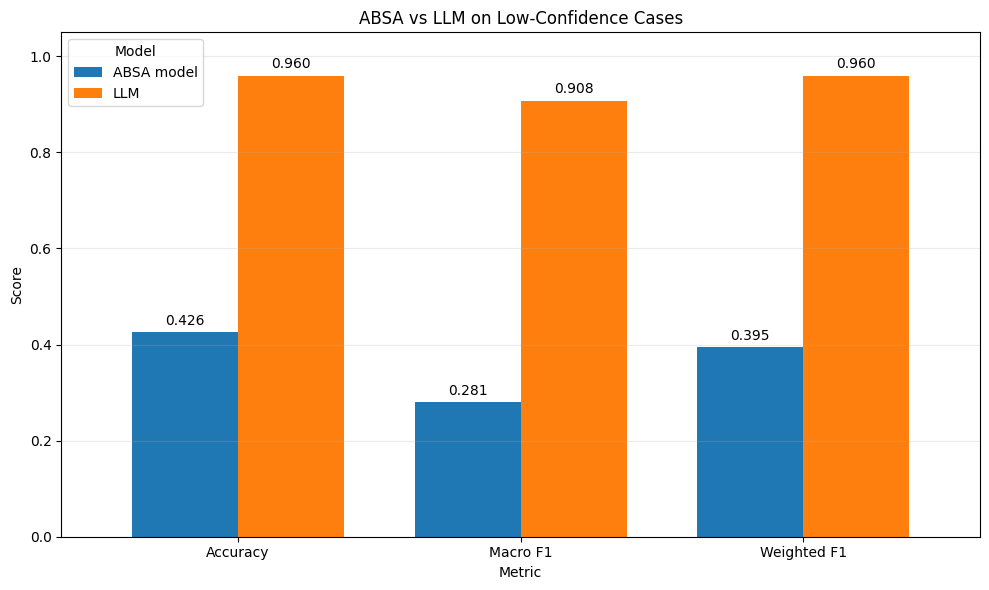

In [23]:
ax = comparison.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title("ABSA vs LLM on Low-Confidence Cases")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import classification_report

labels = ["conflict", "negative", "neutral", "positive"]

absa_report = classification_report(
    y_true,
    y_pred_absa,
    labels=labels,
    output_dict=True,
    zero_division=0
)

llm_report = classification_report(
    y_true,
    y_pred_llm,
    labels=labels,
    output_dict=True,
    zero_division=0
)

f1_comparison = pd.DataFrame({
    "ABSA model": [
        absa_report[label]["f1-score"]
        for label in labels
    ],
    "LLM": [
        llm_report[label]["f1-score"]
        for label in labels
    ]
}, index=labels)

print(f1_comparison)

          ABSA model       LLM
conflict    0.000000  0.750000
negative    0.563187  0.968174
neutral     0.254237  0.951374
positive    0.306709  0.962500


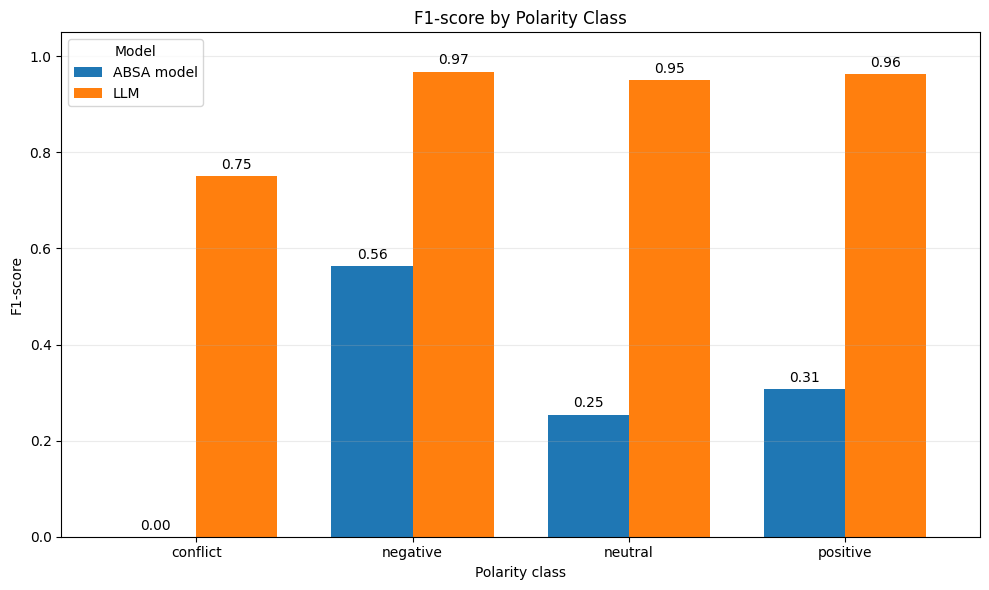

In [25]:
ax = f1_comparison.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title("F1-score by Polarity Class")
plt.xlabel("Polarity class")
plt.ylabel("F1-score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()